<a href="https://colab.research.google.com/github/EngReem85/CPU-Advisor-Predictor/blob/main/CPU_data_cleaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPU Specifications Dataset

## تحميل المكتبات والبيانات

In [ ]:
import numpy as np
import pandas as pd
from pandas.core.api import value_counts
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
df=pd.read_csv('/content/data_cleaned.csv')
df.head(10)

,name,price,tdp,date,socket,category,speed,turbo,cpuCount,cores,logicals,rank,samples
0,AArch64 rev 2 (aarch64),0.0,0.0,2021-02-01,Unknown,Unknown,2189.0,0.0,1,8,1,2164,41
1,AArch64 rev 4 (aarch64),0.0,0.0,2021-01-01,Unknown,Unknown,2112000.0,0.0,1,8,1,2400,81
2,AC8257V/WAB,0.0,0.0,2021-01-01,Unknown,Unknown,2001000.0,0.0,1,8,1,3240,8
3,AMD 3015Ce,0.0,6.0,2021-07-01,FT5,Mobile/Embedded,1200.0,2300.0,1,2,2,2204,40
4,AMD 3015e,0.0,6.0,2020-07-01,Unknown,Laptop,1200.0,2300.0,1,2,2,1918,20
5,AMD 3020e,0.0,6.0,2020-06-01,Unknown,Laptop,1200.0,2600.0,1,2,1,2008,126
6,AMD 4700S,0.0,0.0,2021-04-01,Unknown,Desktop,3600.0,4000.0,1,8,2,408,35
7,AMD A10 Micro-6700T APU,0.0,5.0,2015-05-01,FT3b,Laptop,1200.0,2200.0,1,4,1,2623,9
8,AMD A10 PRO-7350B APU,0.0,19.0,2014-06-01,FP3,Laptop,2100.0,3300.0,1,4,1,2274,142
9,AMD A10 PRO-7800B APU,0.0,65.0,2014-10-01,FM2+,Desktop,3500.0,3900.0,1,2,2,1725,29


## استكشاف البيانات

In [ ]:
df.tail(10)

,name,price,tdp,date,socket,category,speed,turbo,cpuCount,cores,logicals,rank,samples
4449,Intel Xeon X5677 @ 3.47GHz,220.00,130.0,2010-03-01,LGA1366,Server,3470.0,3730.0,2,4,2,341,11
4450,Intel Xeon X5679 @ 3.20GHz,0.00,115.0,2011-12-01,LGA1366,Server,3200.0,3600.0,2,6,2,334,1
4451,Intel Xeon X5680 @ 3.33GHz,330.00,130.0,2010-04-01,LGA1366,Server,3330.0,3600.0,2,6,2,290,109
4452,Intel Xeon X5687 @ 3.60GHz,379.90,130.0,2011-04-01,LGA1366,Server,3600.0,3860.0,2,4,2,336,30
4453,Intel Xeon X5690 @ 3.47GHz,338.94,130.0,2011-03-01,LGA1366,Server,3470.0,3730.0,2,6,2,287,192
4454,Intel Xeon X7350 @ 2.93GHz,442.40,130.0,2014-02-01,604,Server,2930.0,0.0,4,4,1,357,3
4455,Intel Xeon X7460 @ 2.66GHz,404.38,130.0,2015-11-01,PGA604,Server,2660.0,0.0,2,6,1,398,1
4456,Intel Xeon X7550 @ 2.00GHz,200.00,130.0,2014-01-01,LGA1567,Server,2000.0,2400.0,2,8,2,356,1
4457,Intel Xeon X7560 @ 2.27GHz,2200.00,130.0,2011-01-01,LGA1567,Server,2270.0,2666.0,4,8,2,268,3
4458,Intel Xeon X7560 @ 2.27GHz,1100.00,130.0,2011-01-01,LGA1567,Server,2270.0,2666.0,2,8,2,350,1


In [ ]:
df.shape

(4459, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      4459 non-null   object 
 1   price     4459 non-null   float64
 2   tdp       4459 non-null   float64
 3   date      4459 non-null   object 
 4   socket    4459 non-null   object 
 5   category  4459 non-null   object 
 6   speed     4459 non-null   float64
 7   turbo     4459 non-null   float64
 8   cpuCount  4459 non-null   int64  
 9   cores     4459 non-null   int64  
 10  logicals  4459 non-null   int64  
 11  rank      4459 non-null   int64  
 12  samples   4459 non-null   int64  
dtypes: float64(4), int64(5), object(4)
memory usage: 453.0+ KB


In [ ]:
df.columns

Index(['name', 'price', 'tdp', 'date', 'socket', 'category', 'speed', 'turbo',
       'cpuCount', 'cores', 'logicals', 'rank', 'samples'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
name,0
price,0
tdp,0
date,0
socket,0
category,0
speed,0
turbo,0
cpuCount,0
cores,0


In [ ]:
df.describe()

,price,tdp,speed,turbo,cpuCount,cores,logicals,rank,samples
count,4459.000000,4459.000000,4.459000e+03,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000
mean,439.572272,58.312794,2.243759e+04,1895.631756,1.120206,6.015026,1.475667,1825.413770,346.648352
std,1582.694130,54.724551,2.055380e+05,1925.518557,0.405096,7.668022,0.499464,1222.102668,1213.151898
min,0.000000,0.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,15.000000,2.000000e+03,0.000000,1.000000,2.000000,1.000000,665.500000,4.000000
50%,32.870000,45.000000,2.400000e+03,2400.000000,1.000000,4.000000,1.000000,1780.000000,26.000000
75%,229.995000,91.000000,3.000000e+03,3600.000000,1.000000,8.000000,2.000000,2894.500000,163.000000
max,28696.000000,300.000000,2.912000e+06,34000.000000,5.000000,128.000000,2.000000,4009.000000,20920.000000


In [ ]:
df.describe(include='object')

,name,date,socket,category
count,4459,4459,4459,4459
unique,4082,173,219,12
top,Intel Xeon E5-4669 v3 @ 2.10GHz,2009-03-01,Unknown,Server
freq,3,180,868,1268


## تنظيف البيانات

In [ ]:
df['name'].value_counts()

,count
name,
Intel Xeon E5-4669 v3 @ 2.10GHz,3
Intel Xeon Platinum 8260 @ 2.40GHz,3
Intel Xeon E5-4657L v2 @ 2.40GHz,3
AMD Opteron 6276,3
Intel Xeon E5-4650 @ 2.70GHz,3
...,...
Intel Celeron 3.33GHz,1
Intel Celeron 3205U @ 1.50GHz,1
Intel Celeron 3215U @ 1.70GHz,1


In [ ]:

df['extracted_ghz'] = df['name'].str.extract(r'@\s*([\d\.]+)\s*GHz').astype(float)
df['extracted_ghz'].isnull().sum()

np.int64(2027)

In [ ]:
df['brand'] = df['name'].str.split().str[0]
df.loc[~df['brand'].isin(['Intel', 'AMD', 'Apple', 'AArch64', 'Samsung','Microsoft','Qualcomm','Nvidia','VIA','Rockchip','MediaTek', 'QCT','Spreadtrum','Snapdragon','Unisoc']), 'brand'] = 'Other'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4459 non-null   object 
 1   price          4459 non-null   float64
 2   tdp            4459 non-null   float64
 3   date           4459 non-null   object 
 4   socket         4459 non-null   object 
 5   category       4459 non-null   object 
 6   speed          4459 non-null   float64
 7   turbo          4459 non-null   float64
 8   cpuCount       4459 non-null   int64  
 9   cores          4459 non-null   int64  
 10  logicals       4459 non-null   int64  
 11  rank           4459 non-null   int64  
 12  samples        4459 non-null   int64  
 13  extracted_ghz  2432 non-null   float64
 14  brand          4459 non-null   object 
dtypes: float64(5), int64(5), object(5)
memory usage: 522.7+ KB


In [ ]:
df['brand'].value_counts()

,count
brand,
Intel,2593
AMD,1252
Other,319
Qualcomm,107
MediaTek,61
Samsung,25
VIA,23
Rockchip,19
Unisoc,16


In [ ]:
def classify_all_missing_families(name):
    n = str(name).upper()
    # ---  العائلات التاريخية والناشئة ---
    if 'OPTERON' in n: return 'AMD Opteron'
    if 'SEMPRON' in n: return 'AMD Sempron'
    if 'TURION' in n: return 'AMD Turion'
    if 'ITANIUM' in n: return 'Intel Itanium'
    if 'KIRIN' in n or 'HISILICON' in n: return 'Huawei Kirin'
    if 'ROCKCHIP' in n: return 'Rockchip'
    if 'ALLWINNER' in n: return 'Allwinner'
    if 'AMPERE' in n: return 'Ampere (Cloud ARM)'
    if 'T-HEAD' in n or 'C906' in n: return 'RISC-V (T-Head)'
    if 'TEGRA' in n: return 'Nvidia Tegra'
    # --- عائلة Intel ---
    if 'CORE I' in n: return 'Intel Core i-Series'
    if 'CORE 2' in n: return 'Intel Core 2 (Duo/Quad)'
    if 'CORE M' in n: return 'Intel Core M'
    if 'XEON' in n: return 'Intel Xeon'
    if 'PENTIUM' in n: return 'Intel Pentium'
    if 'CELERON' in n: return 'Intel Celeron'
    if 'ATOM' in n: return 'Intel Atom'

    # --- عائلة AMD ---
    if 'RYZEN' in n: return 'AMD Ryzen'
    if 'EPYC' in n: return 'AMD EPYC'
    if 'THREADRIPPER' in n: return 'AMD Threadripper'
    if 'ATHLON' in n: return 'AMD Athlon'
    if 'FX-' in n: return 'AMD FX Series'
    if 'A10-' in n or 'A8-' in n or 'A6-' in n or 'A4-' in n: return 'AMD A-Series (APU)'
    if 'PHENOM' in n: return 'AMD Phenom'

    # --- عائلة ARM/Mobile ---
    if 'APPLE' in n or ' M1' in n or ' M2' in n: return 'Apple Silicon'
    if 'SNAPDRAGON' in n: return 'Qualcomm Snapdragon'
    if 'EXYNOS' in n: return 'Samsung Exynos'
    if 'UNISOC' in n or 'SPREADTRUM' in n: return 'Unisoc/Spreadtrum'
    if 'MEDIATEK' in n or 'MT6' in n: return 'MediaTek'

    return 'Specialized/Generic ARM'

df['final_family'] = df['name'].apply(classify_all_missing_families)
print(df['final_family'].value_counts())

final_family
Intel Xeon                 1034
Intel Core i-Series         831
Specialized/Generic ARM     541
Intel Pentium               261
AMD Athlon                  246
AMD Ryzen                   242
Intel Celeron               235
AMD A-Series (APU)          161
AMD Opteron                 139
MediaTek                    139
AMD Phenom                  123
AMD EPYC                    109
Intel Atom                   87
AMD Turion                   62
AMD Sempron                  49
AMD FX Series                41
Huawei Kirin                 24
Samsung Exynos               22
Unisoc/Spreadtrum            21
Rockchip                     21
Intel Core 2 (Duo/Quad)      20
Intel Core M                 18
Apple Silicon                16
Qualcomm Snapdragon          15
Nvidia Tegra                  2
Name: count, dtype: int64


In [ ]:
def smart_clean_model(row):
    name = str(row['name'])


    name = re.sub(r'(@?\s*[\d\.]+\s*(GHz|MHz|ghz|mhz))', '', name)

    brands = ['Intel', 'AMD', 'Apple', 'Samsung', 'Qualcomm', 'Nvidia', 'MediaTek', 'Unisoc', 'Spreadtrum']
    for b in brands:
        name = re.sub(f'^{b}\s+', '', name, flags=re.IGNORECASE)

    name = name.replace('(TM)', '').replace('(R)', '').replace('Processor', '')

    name = ' '.join(name.split())

    if len(name) < 2:
        return row['name']

    return name

df['model_only'] = df.apply(smart_clean_model, axis=1)

print(df[['name', 'model_only']].head(10))



                      name               model_only
0  AArch64 rev 2 (aarch64)  AArch64 rev 2 (aarch64)
1  AArch64 rev 4 (aarch64)  AArch64 rev 4 (aarch64)
2              AC8257V/WAB              AC8257V/WAB
3               AMD 3015Ce                   3015Ce
4                AMD 3015e                    3015e
5                AMD 3020e                    3020e
6                AMD 4700S                    4700S
7  AMD A10 Micro-6700T APU      A10 Micro-6700T APU
8    AMD A10 PRO-7350B APU        A10 PRO-7350B APU
9    AMD A10 PRO-7800B APU        A10 PRO-7800B APU


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4018701628.py:9: SyntaxWarning: invalid escape sequence '\s'
  name = re.sub(f'^{b}\s+', '', name, flags=re.IGNORECASE)


In [ ]:
df['model_only'].value_counts()

,count
model_only,
Pentium 4,29
Pentium M,22
Celeron,22
Xeon,15
ARM Cortex-A72 4 Core,14
...,...
Xeon E7530,1
Xeon E7450,1
A10-6790K APU,1


In [ ]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price'] = df['price'].replace(0, pd.NA)

In [ ]:
df['price'].value_counts()

,count
price,
250.0,17
281.0,14
426.0,12
107.0,12
29.99,11
...,...
38.0,1
178.85,1
121.98,1


In [ ]:
if df['tdp'].dtype == 'object':
    df['tdp'] = df['tdp'].str.replace('W', '', case=False).str.strip()
    df['tdp'] = pd.to_numeric(df['tdp'], errors='coerce')

In [ ]:
df['tdp'].value_counts()

,count
tdp,
0.0,762
35.0,448
65.0,425
95.0,266
15.0,262
...,...
32.2,1
110.7,1
79.0,1


In [ ]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   name           4459 non-null   object        
 1   price          2454 non-null   object        
 2   tdp            4459 non-null   float64       
 3   date           4459 non-null   datetime64[ns]
 4   socket         4459 non-null   object        
 5   category       4459 non-null   object        
 6   speed          4459 non-null   float64       
 7   turbo          4459 non-null   float64       
 8   cpuCount       4459 non-null   int64         
 9   cores          4459 non-null   int64         
 10  logicals       4459 non-null   int64         
 11  rank           4459 non-null   int64         
 12  samples        4459 non-null   int64         
 13  extracted_ghz  2432 non-null   float64       
 14  brand          4459 non-null   object        
 15  model_only     4459 n

In [ ]:
df['date'].value_counts()

,count
date,
2009-03-01,180
2021-02-01,153
2009-02-01,146
2008-12-01,92
2021-01-01,84
...,...
2022-12-01,4
2016-09-01,2
2008-01-01,2


In [ ]:
df['socket'].value_counts()

,count
socket,
Unknown,868
FCLGA3647,178
AM4,140
LGA1366,104
LGA1155,103
...,...
mPGA604,1
FCLGA-3647,1
PPGA478,1


In [ ]:
df['category'].value_counts()

,count
category,
Server,1268
Laptop,1183
Desktop,1159
Mobile/Embedded,476
Unknown,271
"Laptop, Mobile/Embedded",45
"Desktop, Server",21
"Desktop, Laptop",13
"Laptop, Server",11


In [ ]:
def strictly_map_categories_final(row):

    cat_raw = str(row['category']).upper()
    name = str(row['name']).upper()
    brand = str(row['brand']).upper()

    m_list = ['SNAPDRAGON', 'EXYNOS', 'KIRIN', 'DIMENSITY', 'HELIO', 'MTK', 'UNISOC', 'APPLE A', 'CORTEX', 'ARM']

    if 'SERVER' in cat_raw or 'WORKSTATION' in cat_raw or any(x in name for x in ['XEON', 'EPYC']):
        return 'Server/Workstation'

    if 'EMBEDDED' in cat_raw or 'IOT' in cat_raw or 'INDUSTRIAL' in cat_raw:
        return 'Embedded/IoT'

    if 'TABLET' in cat_raw or any(x in name for x in m_list) or brand in ['QUALCOMM', 'MEDIATEK', 'SPREADTRUM']:
        return 'Mobile / Tablet'

    if 'LAPTOP' in cat_raw or 'NOTEBOOK' in cat_raw or any(x in name for x in ['-U', '-H', '-G', '-M']):
        return 'Laptop'

    if 'DESKTOP' in cat_raw or any(x in name for x in ['I3-', 'I5-', 'I7-', 'I9-', 'RYZEN']):
        return 'Desktop'

    return 'Unknown'

df['category_final'] = df.apply(strictly_map_categories_final, axis=1)

mapping = {
    'Server/Workstation': 'Server/Workstation',
    'Embedded/IoT': 'Embedded/IoT',
    'Mobile / Tablet': 'Mobile / Tablet',
    'Laptop': 'Laptop',
    'Desktop': 'Desktop'
}

df['category_final'] = df['category_final'].apply(lambda x: mapping.get(x, 'Unknown'))

print("--- التوزيع النهائي للفئات الخمس ---")
print(df['category_final'].value_counts())

--- التوزيع النهائي للفئات الخمس ---
category_final
Server/Workstation    1313
Laptop                1195
Desktop               1165
Embedded/IoT           528
Unknown                186
Mobile / Tablet         72
Name: count, dtype: int64


In [ ]:
def final_forensic_clean(row):
    cat = row['category_final']
    name = str(row['name']).upper()
    brand = str(row['brand']).upper()

    if cat == 'Unknown':

        if any(x in brand for x in ['APPLE', 'SAMSUNG', 'QUALCOMM', 'MEDIATEK', 'HISILICON', 'T-HEAD']):
            return 'Mobile / Tablet'

        if any(x in name for x in ['PENTIUM', 'CELERON', 'CORE2', 'DUO', 'QUAD', 'ATHLON', 'PHENOM', 'FX-']):
            if not any(suffix in name for suffix in ['-U', '-M', '-H', '-L', 'MOBILE']):
                return 'Desktop'
            else:
                return 'Laptop'

        if any(x in name for x in ['OPTERON', 'ITANIUM', 'POWERPC', 'SPARC']):
            return 'Server/Workstation'

        if any(x in name for x in ['ATOM', 'GEODE', 'QUARK', 'MIPS', 'VIA ', 'ELAN']):
            return 'Embedded/IoT'

        if re.search(r'^(80\d|680|Z80)', name):
            return 'Desktop'

    return cat

df['category_final'] = df.apply(final_forensic_clean, axis=1)

print("--- التوزيع بعد التحرّي النهائي ---")
print(df['category_final'].value_counts())

--- التوزيع بعد التحرّي النهائي ---
category_final
Server/Workstation    1313
Desktop               1301
Laptop                1195
Embedded/IoT           537
Mobile / Tablet         72
Unknown                 41
Name: count, dtype: int64


In [ ]:
df['speed'].value_counts()

,count
speed,
2000.0,263
2400.0,247
2200.0,217
3000.0,191
2300.0,182
...,...
2184000.0,1
2861.0,1
3140.0,1


In [ ]:
df['turbo'].value_counts()

,count
turbo,
0.0,2105
3600.0,138
4000.0,136
3700.0,136
3200.0,130
...,...
3150.0,1
1733.0,1
1460.0,1


In [ ]:
df['turbo'] = df['turbo'].replace(0, pd.NA)


In [ ]:
def normalize_speed_fixed(val):

    if pd.isna(val):
        return None

    try:
        val = float(val)
    except:
        return None

    if val <= 0:
        return None


    if val > 100000:
        return round(val / 1000000, 2)
    elif val >= 100:
        return round(val / 1000, 2)
    else:
        return round(val, 2)

# تطبيق التعديل بأمان
df['speed_ghz'] = df['speed'].apply(normalize_speed_fixed)
df['turbo_ghz'] = df['turbo'].apply(normalize_speed_fixed)

# عرض النتيجة للتأكد
print(df[['name', 'speed', 'speed_ghz', 'turbo', 'turbo_ghz']].head(10))

                      name      speed  speed_ghz   turbo  turbo_ghz
0  AArch64 rev 2 (aarch64)     2189.0       2.19     0.0        NaN
1  AArch64 rev 4 (aarch64)  2112000.0       2.11     0.0        NaN
2              AC8257V/WAB  2001000.0       2.00     0.0        NaN
3               AMD 3015Ce     1200.0       1.20  2300.0        2.3
4                AMD 3015e     1200.0       1.20  2300.0        2.3
5                AMD 3020e     1200.0       1.20  2600.0        2.6
6                AMD 4700S     3600.0       3.60  4000.0        4.0
7  AMD A10 Micro-6700T APU     1200.0       1.20  2200.0        2.2
8    AMD A10 PRO-7350B APU     2100.0       2.10  3300.0        3.3
9    AMD A10 PRO-7800B APU     3500.0       3.50  3900.0        3.9


In [ ]:
df['speed_ghz'].value_counts()

,count
speed_ghz,
2.00,302
2.40,247
2.20,223
3.00,194
2.30,194
...,...
2.81,1
2.42,1
2.22,1


In [ ]:
df['turbo_ghz'].value_counts()

,count
turbo_ghz,
3.60,138
4.00,136
3.70,136
3.20,130
3.50,128
...,...
3.15,1
2.84,1
1.46,1


In [ ]:
df['cpuCount'].value_counts()

,count
cpuCount,
1,4009
2,407
4,41
5,1
3,1


In [ ]:
df['cores'].value_counts()

,count
cores,
4,1255
2,1251
8,636
1,365
6,320
12,102
16,93
10,92
3,55


In [ ]:
df['logicals'].value_counts()

,count
logicals,
1,2338
2,2121


In [ ]:
df['rank'].value_counts()

,count
rank,
127,2
91,2
429,2
192,2
152,2
...,...
2079,1
1763,1
1820,1


In [ ]:
df['samples'].value_counts()

,count
samples,
1,445
2,366
3,209
4,150
5,136
...,...
1730,1
2667,1
2139,1


## تحليل البيانات

In [ ]:
brand_price = df.dropna(subset=['price']).groupby('brand')['price'].mean().sort_values(ascending=False)
print("متوسط الأسعار حسب الشركة:")
print(brand_price)

متوسط الأسعار حسب الشركة:
brand
Intel    815.283355
AMD      755.381003
Other        206.56
Name: price, dtype: object


In [ ]:
expensive_cpu = df.loc[df['price'].idxmax()]

print("تفاصيل أغلى معالج في البيانات:")
print(f"الاسم: {expensive_cpu['name']}")
print(f"السعر: {expensive_cpu['price']} $")
print(f"الشركة: {expensive_cpu['brand']}")
print(f"عدد الأنوية: {expensive_cpu['cores']}")


تفاصيل أغلى معالج في البيانات:
الاسم: Intel Xeon E7-8890 v3 @ 2.50GHz
السعر: 28696.0 $
الشركة: Intel
عدد الأنوية: 18


In [ ]:
cheapest = df.loc[df['price'].idxmin()]
cheapest

,86
name,AMD A6-3410MX APU
price,3.99
tdp,45.0
date,2011-07-01 00:00:00
socket,FS1
category,Laptop
speed,1600.0
turbo,2300.0
cpuCount,1
cores,4


In [ ]:
category_finance = df.groupby('category_final')['price'].agg(['mean', 'max', 'min'])
category_finance

,mean,max,min
category_final,,,
Desktop,185.851714,7462.95,7.99
Embedded/IoT,220.996429,472.0,20.0
Laptop,247.395762,1535.11,3.99
Mobile / Tablet,NaN,NaN,NaN
Server/Workstation,1529.034809,28696.0,9.1
Unknown,108.276364,504.27,12.0


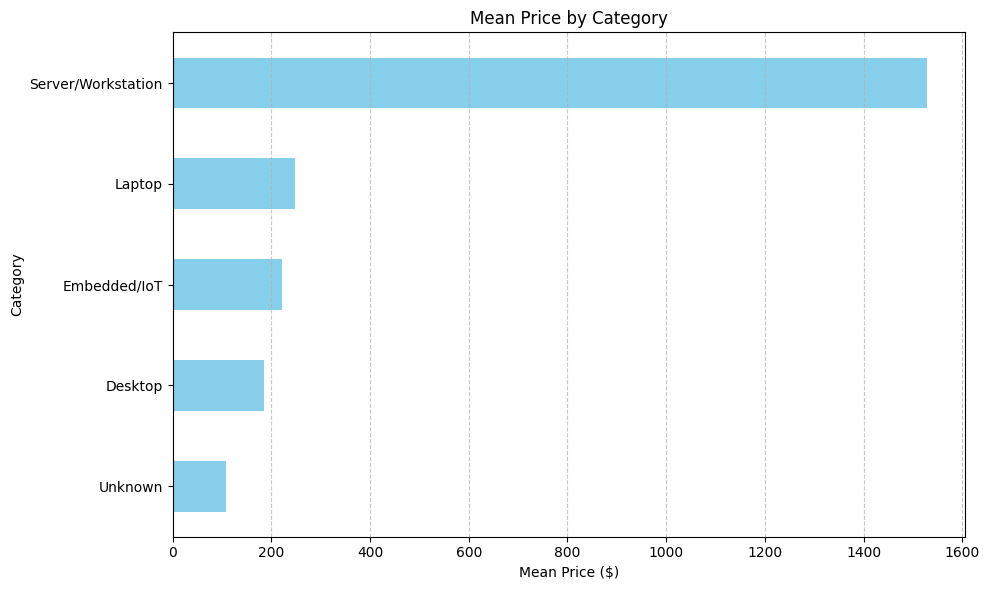

In [ ]:
plot_data = category_finance['mean'].dropna().sort_values()

plt.figure(figsize=(10, 6))
plot_data.plot(kind='barh', color='skyblue')
plt.title('Mean Price by Category')
plt.xlabel('Mean Price ($)')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df['cost_per_core'] = df['price'] / df['cores']
df['cost_per_core'].value_counts()

,count
cost_per_core,
32.0,15
62.5,13
140.5,13
53.5,10
25.0,10
...,...
170.3775,1
107.5,1
32.96,1


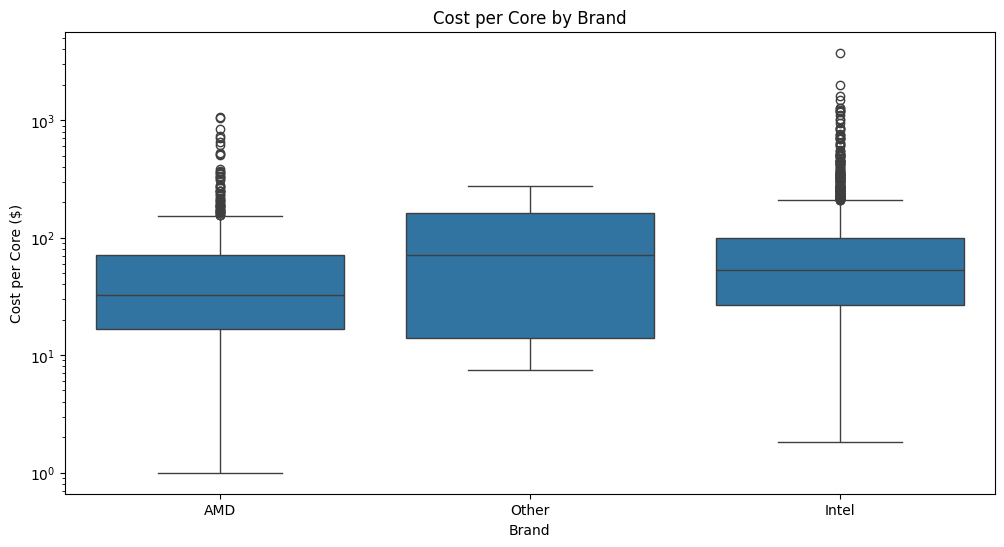

In [ ]:
df['cost_per_core'] = df['cost_per_core'].round(1)
df_filtered = df[df['cost_per_core'] < 1000]
plot_df = df[df['cost_per_core'] > 0].copy()
plt.figure(figsize=(12, 6))
sns.boxplot(x='brand', y='cost_per_core', data=plot_df)
plt.title('Cost per Core by Brand')
plt.xlabel('Brand')
plt.ylabel('Cost per Core ($)')
plt.yscale('log')
plt.show()

/tmp/ipython-input-1863842243.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='brand', y='price', data=df_filtered, palette='viridis', errorbar=None)


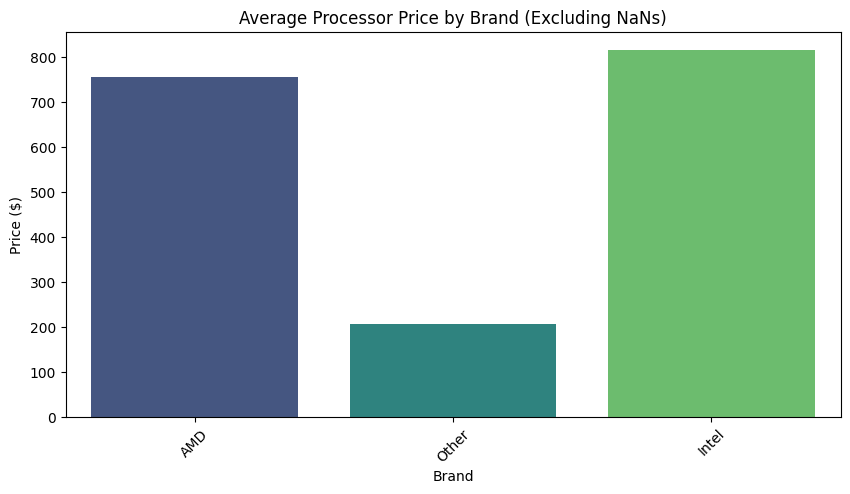

In [ ]:
df_filtered = df.dropna(subset=['price'])

plt.figure(figsize=(10, 5))
sns.barplot(x='brand', y='price', data=df_filtered, palette='viridis', errorbar=None)
plt.title('Average Processor Price by Brand (Excluding NaNs)')
plt.ylabel('Price ($)')
plt.xlabel('Brand')
plt.xticks(rotation=45)
plt.show()

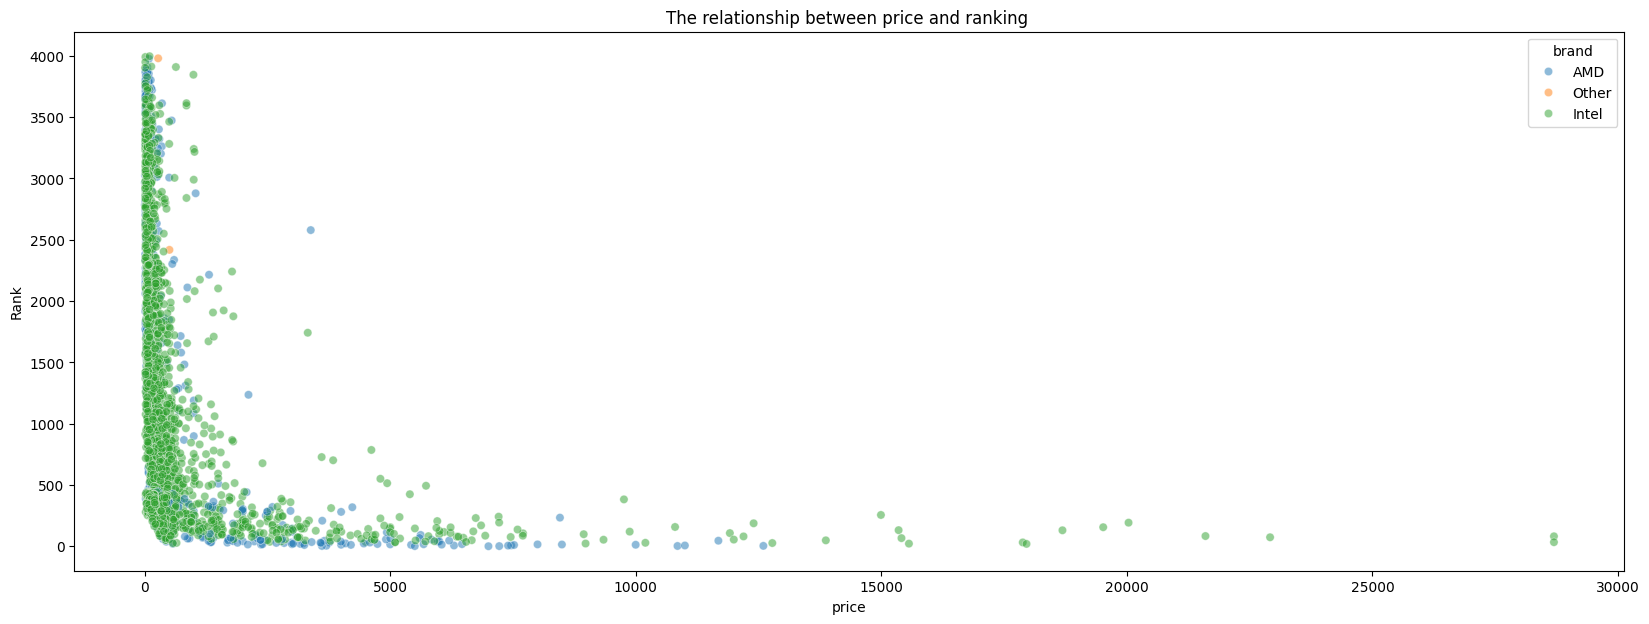

In [ ]:
df_filtered = df.dropna(subset=['price'])
plt.figure(figsize=(20, 7))
sns.scatterplot(x='price', y='rank', hue='brand', data=df_filtered, alpha=0.5)
plt.title('The relationship between price and ranking ')
plt.xlabel('price')
plt.ylabel('Rank')
plt.show()

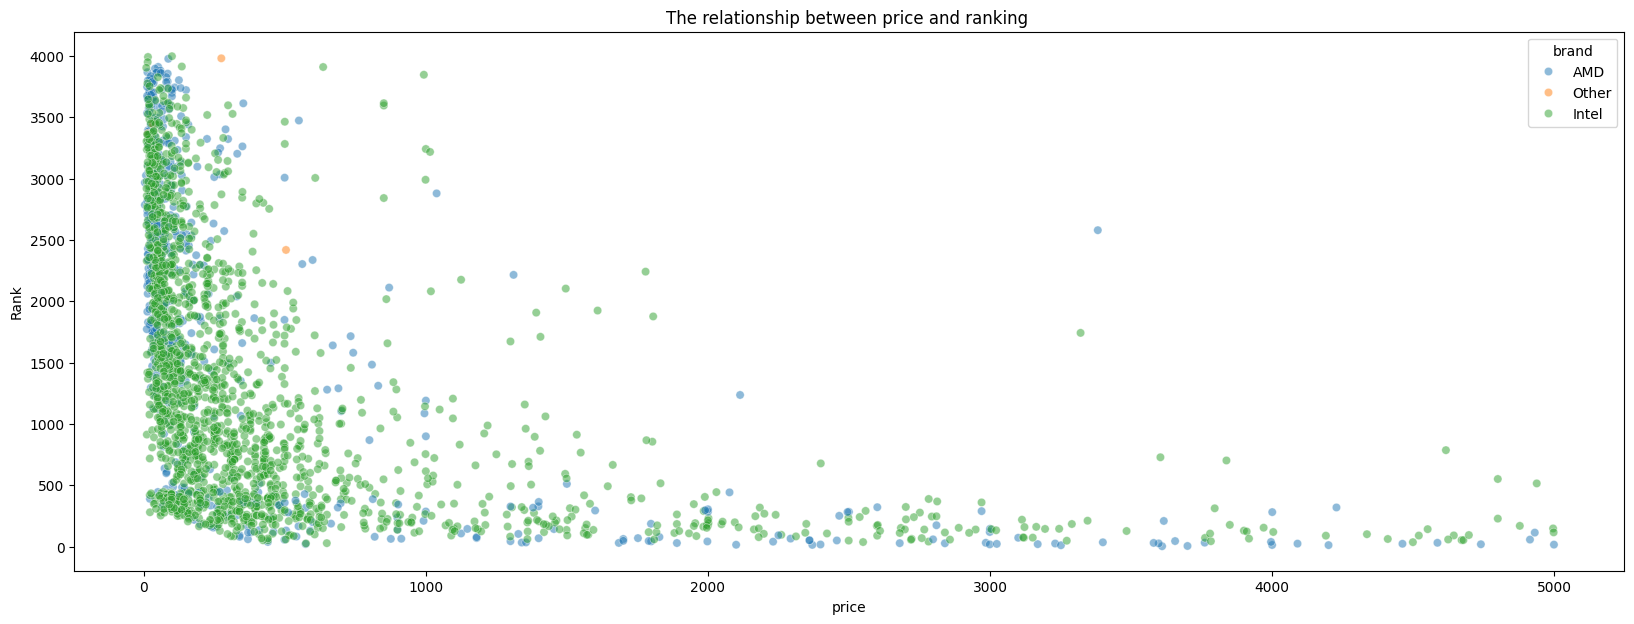

In [ ]:
df_filtered = df[df['price'] < 5000]
plt.figure(figsize=(20, 7))
sns.scatterplot(x='price', y='rank', hue='brand', data=df_filtered, alpha=0.5)
plt.title('The relationship between price and ranking ')
plt.xlabel('price')
plt.ylabel('Rank')
plt.show()

In [ ]:
budget_range = df[(df['price'] >= 0) & (df['price'] <= 1000)]

tech_comparison = budget_range.groupby('brand')[['cores', 'speed_ghz', 'turbo_ghz']].mean()
print(tech_comparison)

          cores  speed_ghz  turbo_ghz
brand                                
AMD    3.981096   2.782854   3.839241
Intel  4.767275   2.647063   3.704537
Other  2.250000   1.900000        NaN


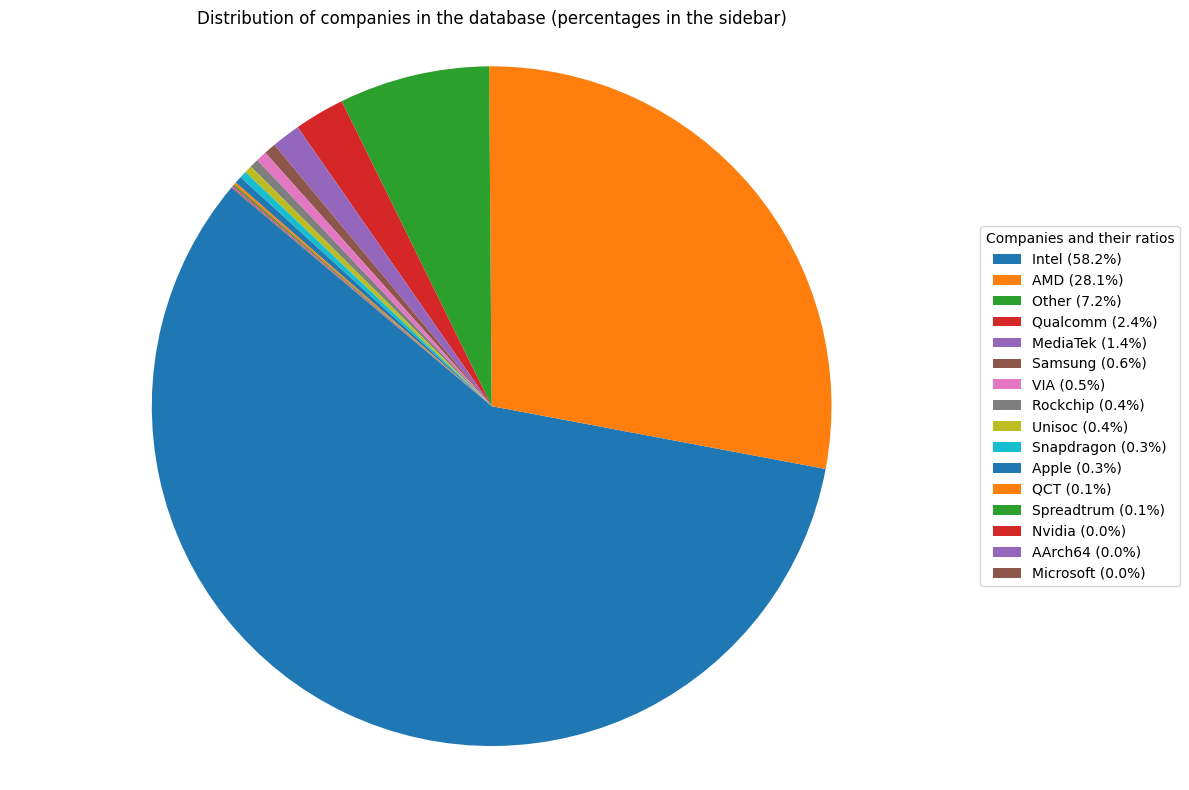

In [ ]:
brand_counts = df['brand'].value_counts()
total = brand_counts.sum()

legend_labels = [f'{n} ({100*v/total:.1f}%)' for n, v in zip(brand_counts.index, brand_counts.values)]
plt.figure(figsize=(12, 8))
patches, texts = plt.pie(brand_counts,
                         startangle=140)

plt.legend(patches, legend_labels,
           title="Companies and their ratios",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1),
           fontsize=10)

plt.title('Distribution of companies in the database (percentages in the sidebar)')
plt.axis('equal')
plt.tight_layout()
plt.show()

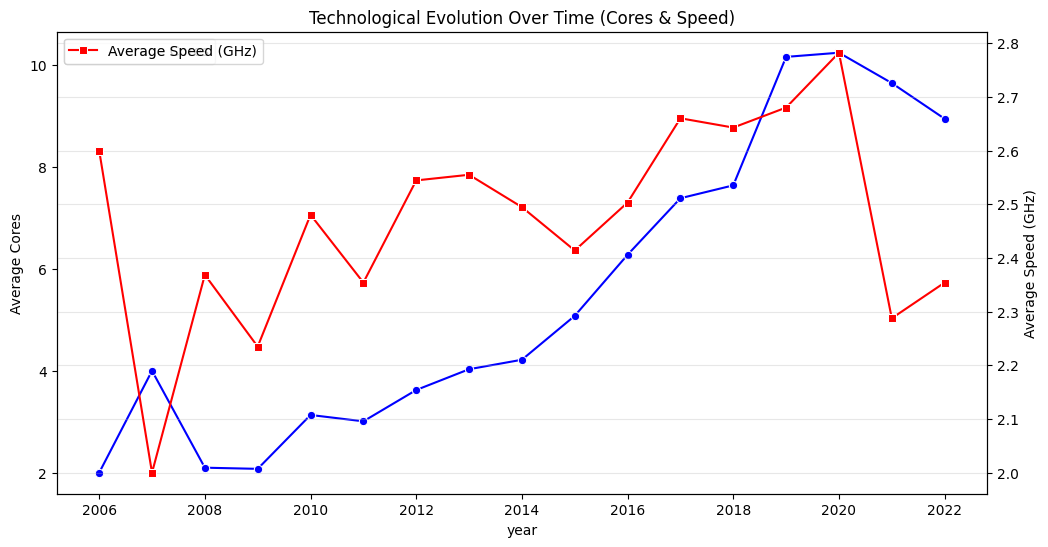

In [ ]:
df['year'] = pd.to_datetime(df['date']).dt.year
yearly_tech = df.groupby('year')[['cores', 'speed_ghz']].mean().reset_index()
plt.figure(figsize=(12, 6))
ax1 = sns.lineplot(data=yearly_tech, x='year', y='cores', marker='o', label='Average Cores', color='blue')
plt.ylabel('Average Cores')
ax2 = ax1.twinx()
sns.lineplot(data=yearly_tech, x='year', y='speed_ghz', marker='s', label='Average Speed (GHz)', color='red', ax=ax2)
plt.ylabel('Average Speed (GHz)')
plt.title('Technological Evolution Over Time (Cores & Speed)')
plt.grid(True, alpha=0.3)
plt.show()

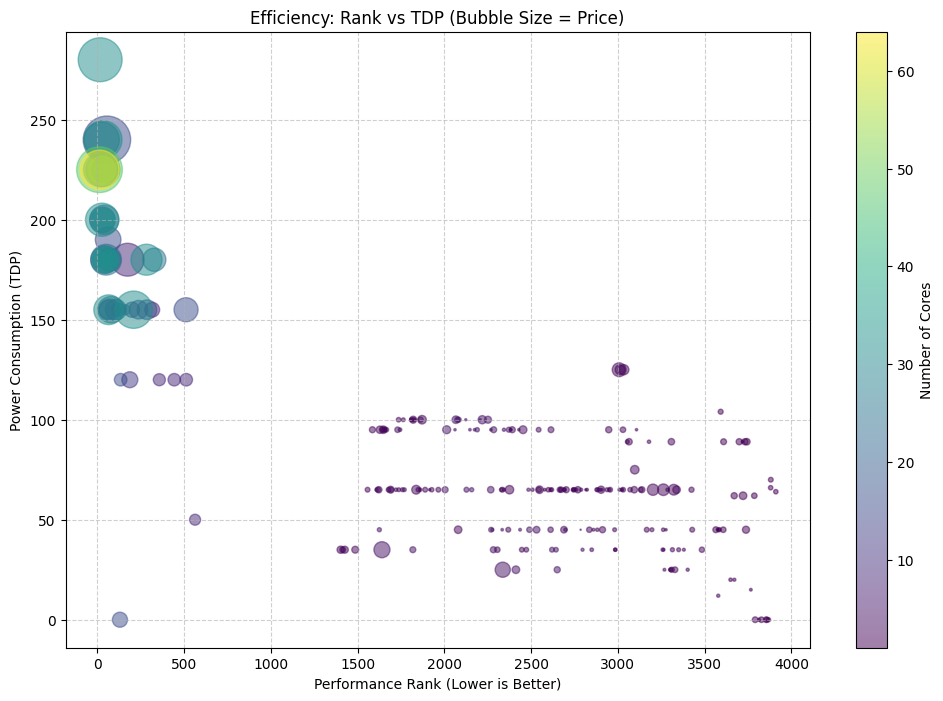

In [ ]:
bubble_df = df.dropna(subset=['rank', 'tdp', 'price']).copy()

bubble_df['rank'] = pd.to_numeric(bubble_df['rank'], errors='coerce')
bubble_df['tdp'] = pd.to_numeric(bubble_df['tdp'], errors='coerce')
bubble_df['price'] = pd.to_numeric(bubble_df['price'], errors='coerce')
bubble_df['cores'] = pd.to_numeric(bubble_df['cores'], errors='coerce')

bubble_df = bubble_df.dropna(subset=['rank', 'tdp', 'price', 'cores'])

bubble_df = bubble_df[bubble_df['price'] > 0].head(250)

bubble_sizes = (bubble_df['price'].values / 5).astype(float)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(x=bubble_df['rank'].values,
                      y=bubble_df['tdp'].values,
                      s=bubble_sizes,
                      alpha=0.5,
                      c=bubble_df['cores'].values,
                      cmap='viridis')

plt.colorbar(scatter, label='Number of Cores')
plt.title('Efficiency: Rank vs TDP (Bubble Size = Price)')
plt.xlabel('Performance Rank (Lower is Better)')
plt.ylabel('Power Consumption (TDP)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipython-input-3617000065.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='value_score', y='name', data=top_10_value, palette='magma')


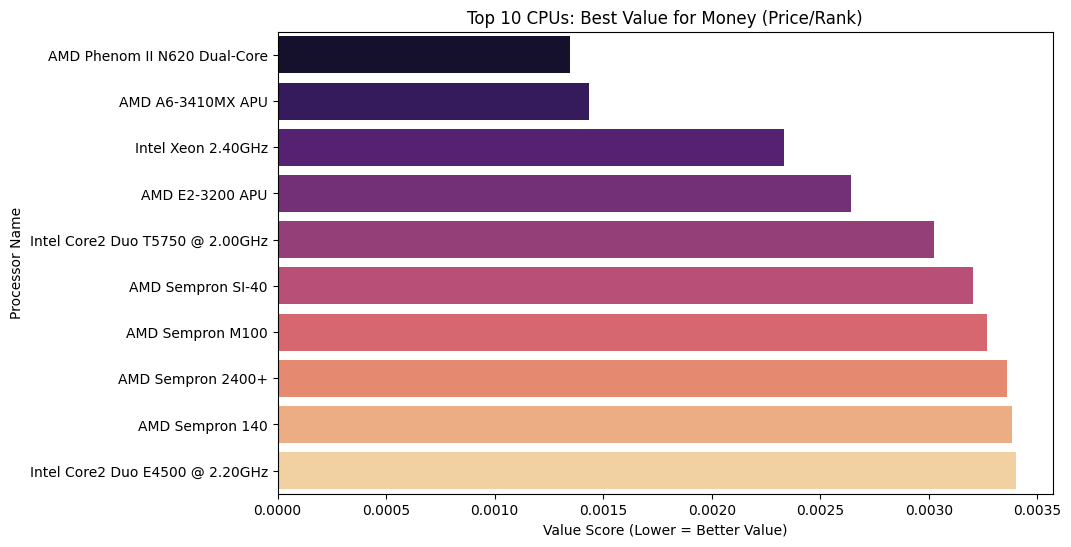

In [ ]:
value_df = df[df['price'] > 0].copy()
value_df['value_score'] = value_df['price'] / value_df['rank']

top_10_value = value_df.sort_values('value_score').head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='value_score', y='name', data=top_10_value, palette='magma')

plt.title('Top 10 CPUs: Best Value for Money (Price/Rank)')
plt.xlabel('Value Score (Lower = Better Value)')
plt.ylabel('Processor Name')
plt.show()

In [ ]:
df.to_csv('Final_CPU_Data_Cleaned.csv')

print("✅ تم حفظ الملف بنجاح باسم: Final_CPU_Data_Cleaned.csv")

✅ تم حفظ الملف بنجاح باسم: Final_CPU_Data_Cleaned.csv
